In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Load the dataset
df = pd.read_csv('BlinkIT Grocery Data.csv')

In [75]:
display(df.head())
display(df.info())
display(df.describe())
display(df.isnull().sum())
display(df.dtypes)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Total Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   str    
 1   Item Identifier            8523 non-null   str    
 2   Item Type                  8523 non-null   str    
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   str    
 5   Outlet Location Type       8523 non-null   str    
 6   Outlet Size                8523 non-null   str    
 7   Outlet Type                8523 non-null   str    
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Total Sales                8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


None

,Outlet Establishment Year,Item Visibility,Item Weight,Total Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Total Sales                     0
Rating                          0
dtype: int64

Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Item Weight                  float64
Total Sales                  float64
Rating                       float64
dtype: object

In [76]:
print(df['Item Fat Content'].unique())

<StringArray>
['Regular', 'Low Fat', 'low fat', 'LF', 'reg']
Length: 5, dtype: str


In [77]:
df['Item Fat Content'] = df['Item Fat Content'].replace({
    'LF': 'Low Fat', 
    'low fat': 'Low Fat',
    'reg': 'Regular'})

In [78]:
print(df['Item Fat Content'].unique())

<StringArray>
['Regular', 'Low Fat']
Length: 2, dtype: str


In [79]:
total_sales = df['Total Sales'].sum()
print(f'Total Sales: {total_sales}')
avg_sales = df['Total Sales'].mean()
print(f'Average Sales: {avg_sales}')
no_of_items = df['Total Sales'].count()
print(f'Number of Items: {no_of_items}')
avg_rating = df['Rating'].mean()
print(f'Average Rating: {avg_rating}')

Total Sales: 1201681.4808
Average Sales: 140.9927819781767
Number of Items: 8523
Average Rating: 3.965857092573038


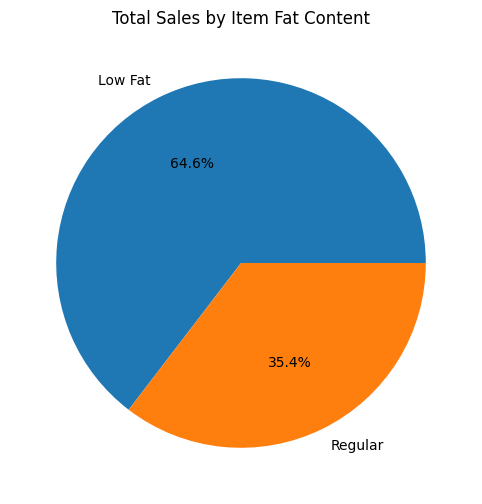

In [80]:
#Total Sales by Fat Content
plt.figure(figsize=(8, 6))
sales_by_fat = df.groupby('Item Fat Content')['Total Sales'].sum()
sales_by_fat.plot(kind='pie', autopct='%.1f%%')
plt.title('Total Sales by Item Fat Content')   
plt.show()

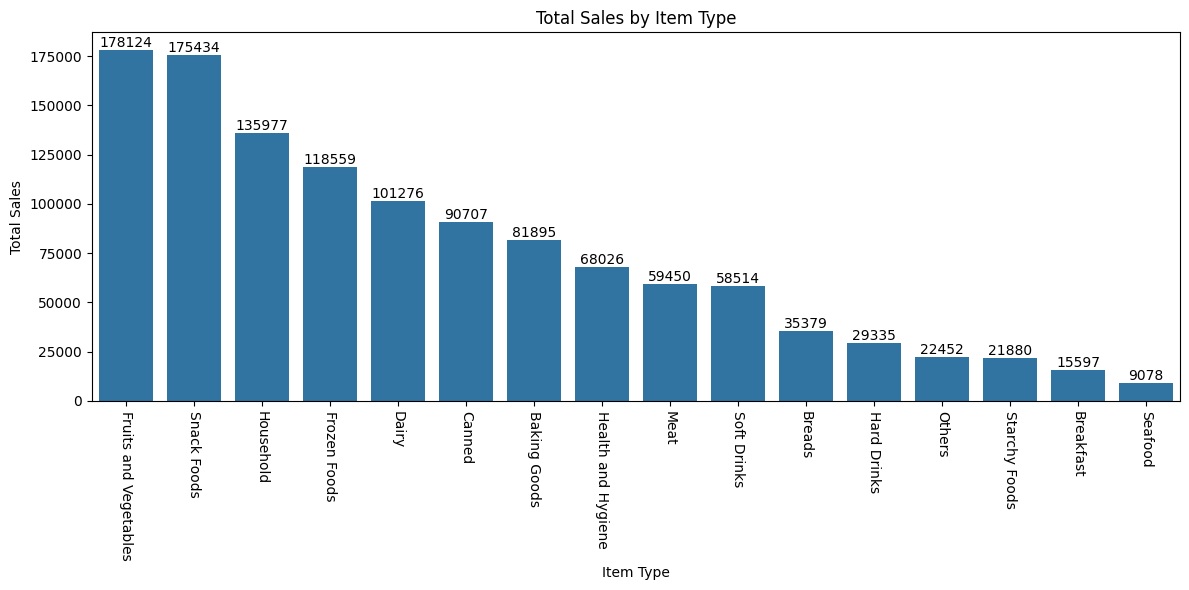

In [81]:
#Total Sales by Item Type
sales_by_item_type = df.groupby('Item Type')['Total Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6)) 
sns.barplot(x=sales_by_item_type.index, y=sales_by_item_type.values)
plt.title('Total Sales by Item Type')
plt.xticks(rotation=-90) 
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
for index, value in enumerate(sales_by_item_type.values):
    plt.text(index, value, f'{value:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

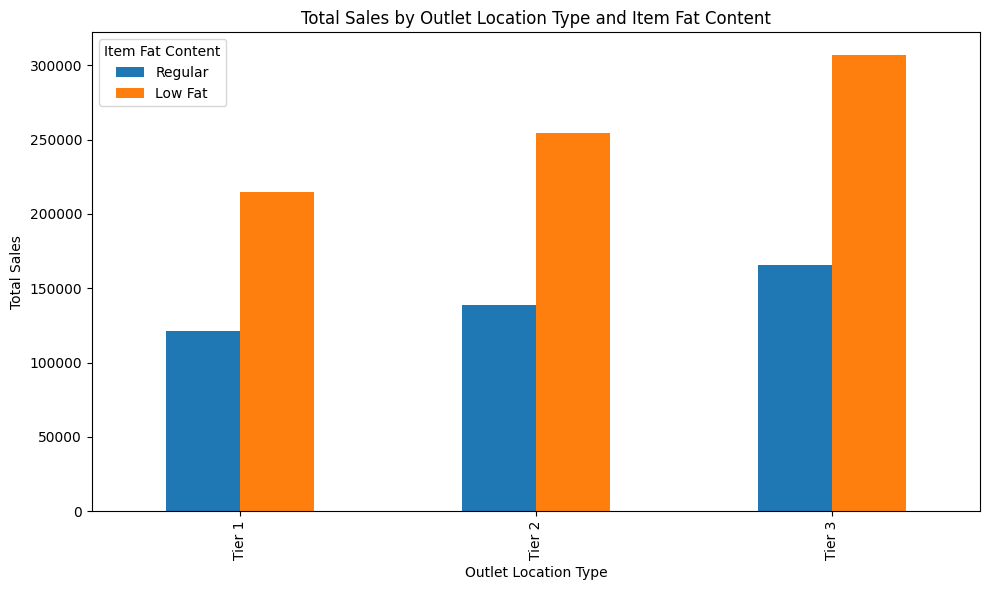

In [82]:
#Fat Content by Outlet for Total Sales
grouped_sales = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Total Sales'].sum().unstack()
grouped_sales = grouped_sales[['Regular', 'Low Fat']]
ax = grouped_sales.plot(kind='bar', figsize=(10, 6))
plt.title('Total Sales by Outlet Location Type and Item Fat Content')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

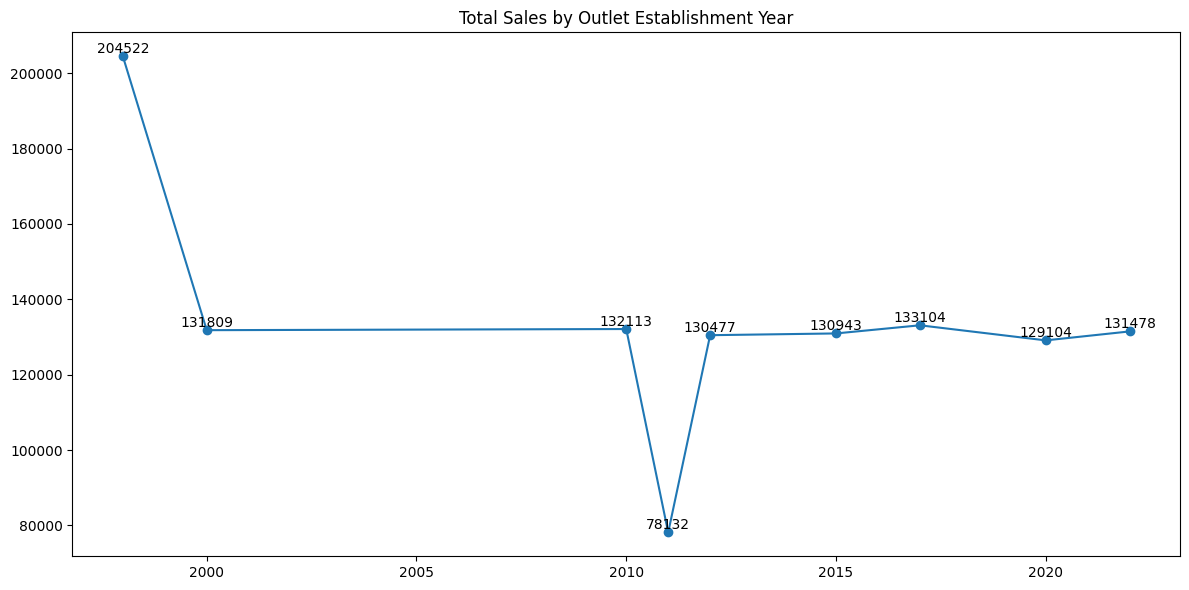

In [83]:
#Total Sales by Outlet Establishment Year
plt.figure(figsize=(12,6))
#Total Sales by Outlet Establishment Year
plt.figure(figsize=(12,6))
sales_by_year = df.groupby('Outlet Establishment Year')['Total Sales'].sum()
plt.plot(sales_by_year.index, sales_by_year.values, marker='o')
plt.title('Total Sales by Outlet Establishment Year')
for year in sales_by_year.index:
    total_sales_year = sales_by_year.loc[year]
    plt.text(year, total_sales_year, f'{total_sales_year:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

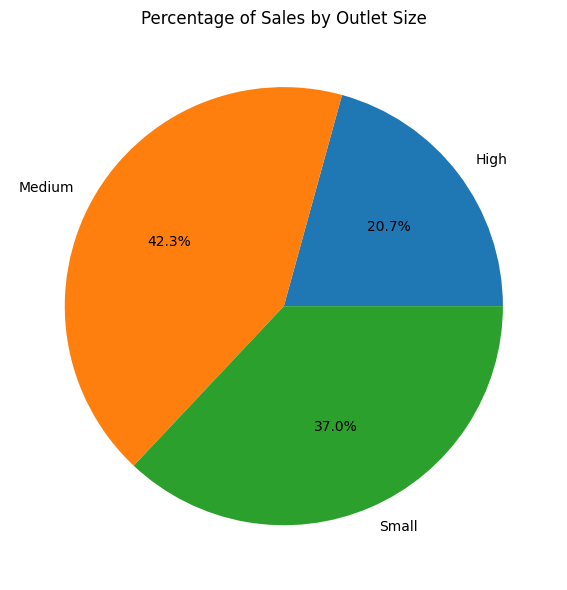

In [84]:
#Percentage of Sales by Outlet Size
plt.figure(figsize=(8, 6))
sales_by_outlet_size = df.groupby('Outlet Size')['Total Sales'].sum()   
sales_by_outlet_size.plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentage of Sales by Outlet Size')
plt.tight_layout()
plt.show()

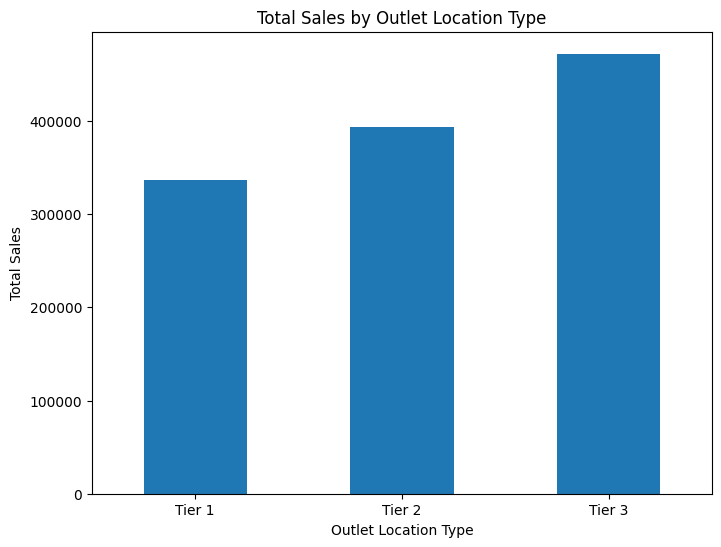

In [85]:
#Sales by Outlet Location
plt.figure(figsize=(8, 6))
sales_by_location = df.groupby('Outlet Location Type')['Total Sales'].sum() 
sales_by_location.plot(kind='bar')
plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()